In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

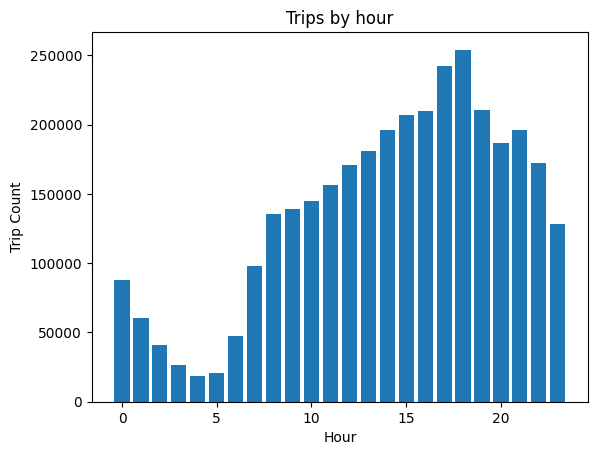

In [ ]:
#trips by hour

trip_hour = pd.read_parquet('../data/marts/mart_hourly_demand.parquet').reset_index()

plt.Figure(figsize = (10,5))
plt.title('Trips by hour')

plt.bar(trip_hour['pickup_hour'],trip_hour['trip_count'])

plt.xlabel('Hour')
plt.ylabel('Trip Count')
plt.xticks()
plt.show()


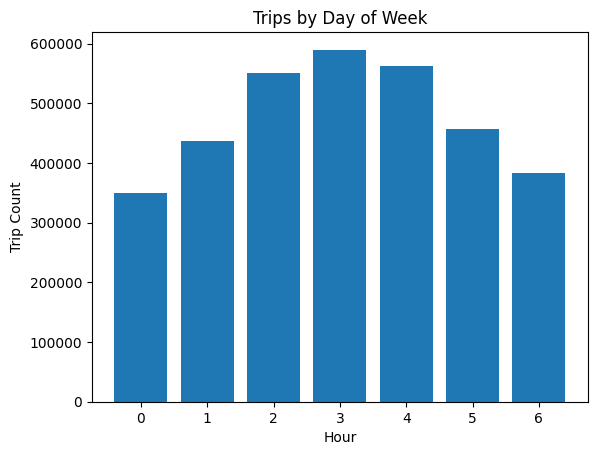

In [ ]:
#trips by day

daily_trip = pd.read_parquet('../data/marts/mart_daily_demand.parquet').reset_index()

plt.Figure(figsize = (10,5))
plt.title('Trips by Day of Week')

plt.bar(daily_trip['pickup_dayofw'],daily_trip['trip_count'])

plt.xlabel('Hour')
plt.ylabel('Trip Count')
plt.xticks()
plt.show()



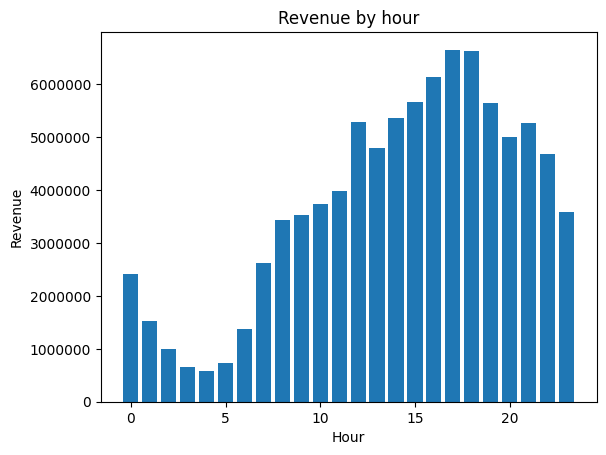

In [27]:
#Revenue by hour

revenue_hour = pd.read_parquet('../data/marts/mart_hourly_demand.parquet').reset_index()

plt.Figure(figsize = (10,5))
plt.title('Revenue by hour')

plt.bar(trip_hour['pickup_hour'],trip_hour['revenue'])

plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.ticklabel_format(style = 'plain',axis = 'y')
plt.xticks()
plt.show()

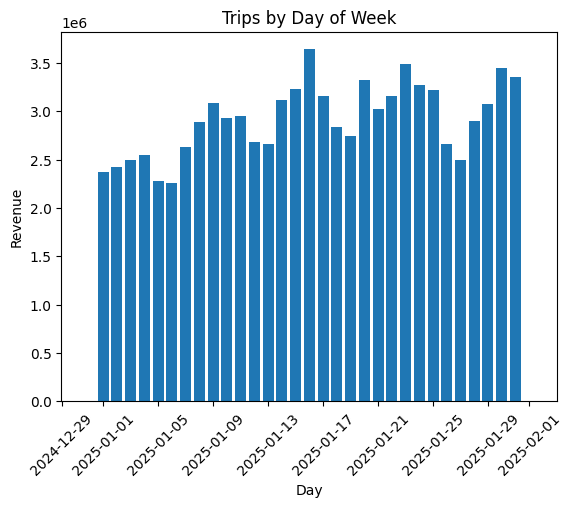

In [37]:
#Revenue by day

df = pd.read_parquet('../data/processed/clean_yellow_2025-01.parquet')

revenue_day = (
    df.groupby('pickup_date')
    .agg(
        total_passenger = ('passenger_count','sum'),
        trip_count = ('tpep_pickup_datetime','count'),
        avg_trip_distance =('trip_distance','mean'),
        revenue= ("total_amount","sum"),
        avg_tip_rate = ('tip_rate','mean'),
        avg_duration = ('duration_mins','mean')
    )
    .sort_values('pickup_date', ascending = False)
    .reset_index()
)
revenue_day['avg_tip_rate'] = revenue_day['avg_tip_rate'] * 100
plt.Figure(figsize = (10,5))
plt.title('Trips by Day of Week')

plt.bar(revenue_day['pickup_date'],revenue_day['revenue'])

plt.xlabel('Day')
plt.ylabel('Revenue')
plt.xticks(rotation = 45)
plt.show()

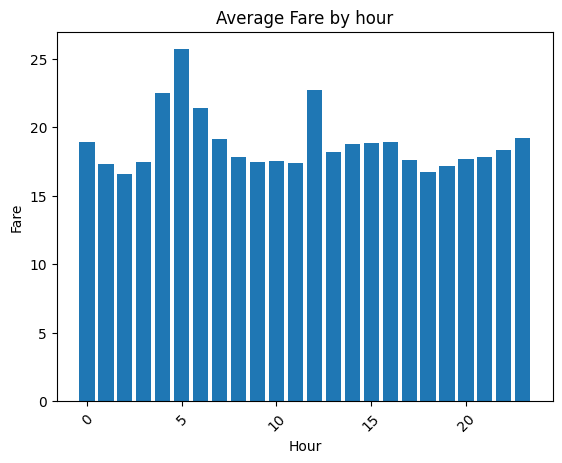

In [40]:
#Average fare by hour

Avg_fare_hour = (
    df.groupby('pickup_hour')
    .agg(
        avg_fare = ('fare_amount','mean')
    )
    .sort_values('pickup_hour', ascending = False)
    .reset_index()
)
plt.Figure(figsize = (10,5))
plt.title('Average Fare by hour')

plt.bar(Avg_fare_hour ['pickup_hour'],Avg_fare_hour ['avg_fare'])

plt.xlabel('Hour')
plt.ylabel('Fare')
plt.xticks(rotation = 45)
plt.show()

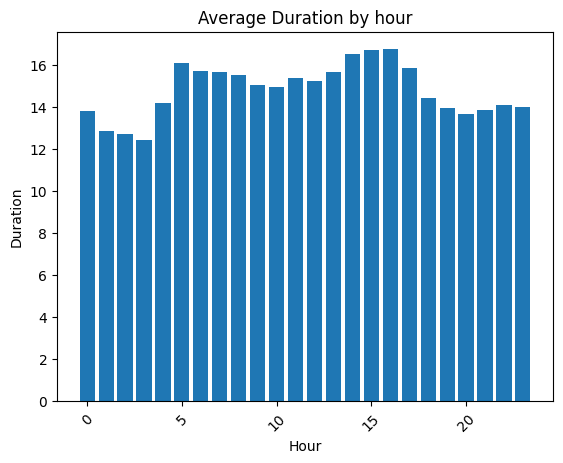

In [41]:
#Average duration by hour

avg_duration_hour = (
    df.groupby('pickup_hour')
    .agg(
        avg_duration = ('duration_mins','mean')
    )
    .sort_values('pickup_hour', ascending = False)
    .reset_index()
)
plt.Figure(figsize = (10,5))
plt.title('Average Duration by hour')

plt.bar(avg_duration_hour ['pickup_hour'],avg_duration_hour ['avg_duration'])

plt.xlabel('Hour')
plt.ylabel('Duration')
plt.xticks(rotation = 45)
plt.show()

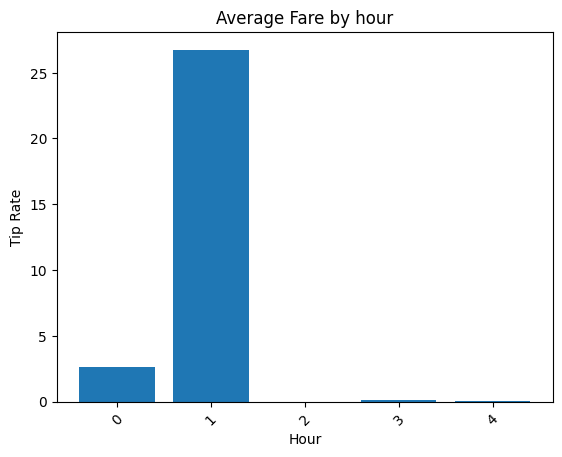

In [44]:
#Tip rate by payment

tip_payment =  pd.read_parquet('../data/marts/mart_tip_behavior.parquet').reset_index()
plt.Figure(figsize = (10,5))
plt.title('Average Fare by hour')

plt.bar(tip_payment['payment_type'],tip_payment ['avg_tip_rate'])

plt.xlabel('Hour')
plt.ylabel('Tip Rate')
plt.xticks(rotation = 45)
plt.show()

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone


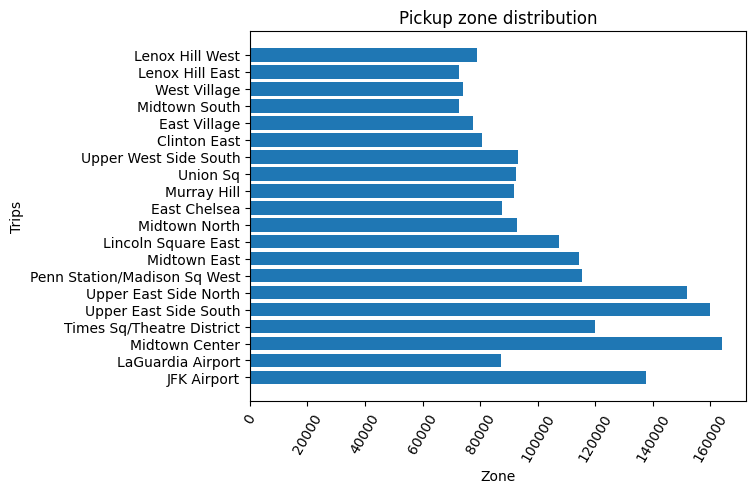

In [56]:
#Top pick up zones

pickup_demand=  pd.read_parquet('../data/marts/mart_pickup_demand.parquet').reset_index().head(20)
taxi_zone = pd.read_csv('../data/raw/taxi_zone_lookup.csv')

print(taxi_zone.head())

pickup_demand = pickup_demand.merge(
    taxi_zone[['LocationID','Zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).rename(columns = {'Zone':'pickup_zone'}).drop(columns=['LocationID'])

plt.Figure(figsize = (10,5))
plt.title('Pickup zone distribution')

plt.barh(pickup_demand['pickup_zone'].astype(str),pickup_demand ['trip_count'])

plt.xlabel('Zone')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone


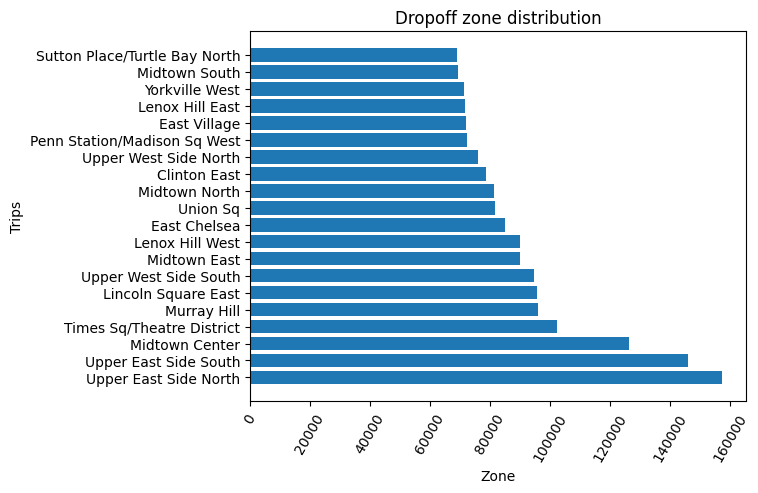

In [ ]:
#common drop off zones

dropoff_common =  pd.read_parquet('../data/marts/mart_dropoff_common.parquet').reset_index().head(20)
taxi_zone = pd.read_csv('../data/raw/taxi_zone_lookup.csv')

dropoff_common = dropoff_common.merge(
    taxi_zone[['LocationID','Zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).rename(columns = {'Zone':'pickup_zone'}).drop(columns=['LocationID'])

plt.Figure(figsize = (10,5))
plt.title('Dropoff zone distribution')

plt.barh(dropoff_common['pickup_zone'].astype(str),dropoff_common ['trip_count'])

plt.xlabel('Zone')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()

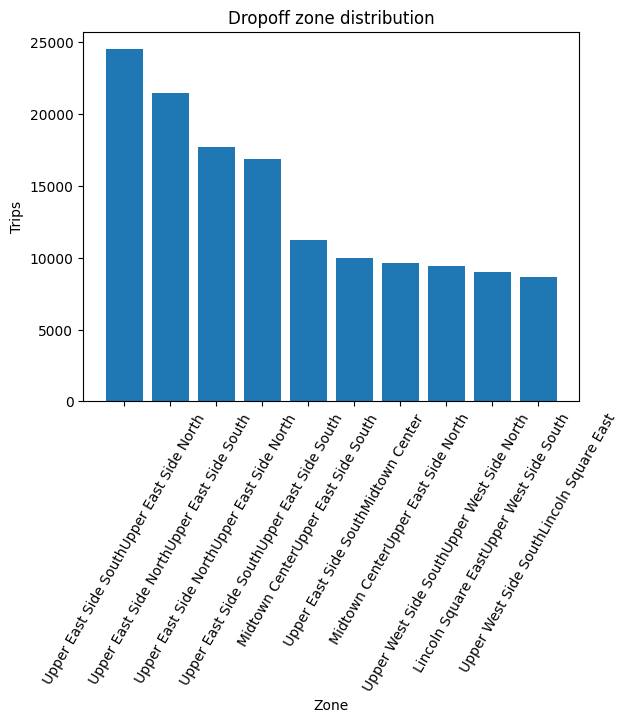

In [64]:
#Top pickup dropoff pair

pudo_pair = (
    df.groupby(['PULocationID','DOLocationID'])
    .agg(trip_count = ('tpep_pickup_datetime','count'))
    .sort_values('trip_count', ascending = False)
    .reset_index()
)

pudo_pair = pudo_pair.merge(
    taxi_zone[['LocationID','Zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).rename(columns = {'Zone':'dropoff_zone'}).drop(columns=['LocationID'])

pudo_pair = pudo_pair.merge(
    taxi_zone[['LocationID','Zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).rename(columns = {'Zone':'pickup_zone'}).drop(columns=['LocationID'])

pudo_pair['pair_name'] = pudo_pair['pickup_zone'] + pudo_pair['dropoff_zone']

top_10_pair = pudo_pair.head(10)
plt.Figure(figsize = (10,5))
plt.title('Dropoff zone distribution')

plt.bar(top_10_pair['pair_name'],top_10_pair ['trip_count'])

plt.xlabel('Zone')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()

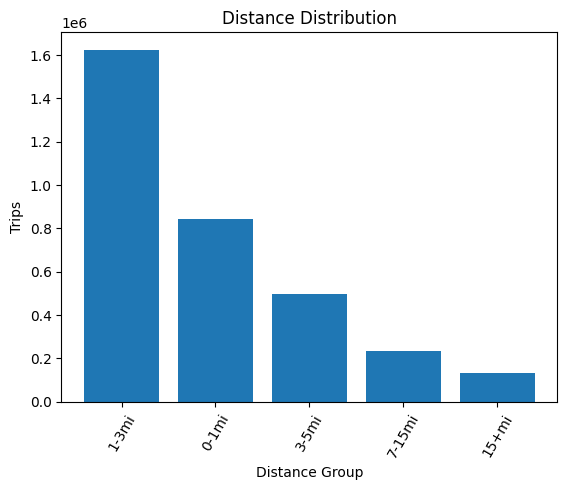

In [63]:
#Distance distribution

trip_distribution =  pd.read_parquet('../data/marts/mart_trip_distribution.parquet').reset_index()

plt.Figure(figsize = (10,5))
plt.title('Distance Distribution')

plt.bar(trip_distribution['distance_group'].astype(str),trip_distribution ['trip_count'])

plt.xlabel('Distance Group')
plt.ylabel('Trips')
plt.xticks(rotation = 60)
plt.show()